In this notebook, we will generate synthetic stellar samples using TRILEGAL for the Kepler and K2 fields.

K2: https://archive.stsci.edu/missions-and-data/k2/campaign-fields.html#c1 and https://archive.stsci.edu/missions-and-data/k2/documents/data-release-notes

TRILEGAL: https://stev.oapd.inaf.it/cgi-bin/trilegal_1.6 

In [1]:
import os
import os.path
import numpy as np
from numpy import log, exp, pi
import pandas as pd
import scipy
import random
from scipy.stats import gaussian_kde, loguniform, gamma
from math import lgamma
from tqdm import tqdm
from ast import literal_eval
from glob import glob
from tqdm import tqdm
from itertools import zip_longest
import numpy.ma as ma # for masked arrays
from astropy.table import Table, join
import astropy.coordinates as coord
import astropy.units as u
import gala.dynamics as gd
import gala.potential as gp
from pyia import GaiaData

# these packages are for fitting with numpyro
import numpyro
from numpyro import distributions as dist, infer
import numpyro_ext
import arviz as az
import jax

# these are psps imports
from psps.transit_class import Population, Star
import psps.simulate_helpers as simulate_helpers
import psps.simulate_transit as simulate_transit
import psps.utils as utils

# plotting imports
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
matplotlib.rcParams.update({'errorbar.capsize': 1})
pylab_params = {'legend.fontsize': 'large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large'}
pylab.rcParams.update(pylab_params)

import warnings
warnings.filterwarnings("ignore")

path = '/Users/chrislam/Desktop/psps/' 

# we're gonna need this for reading in the initial Berger+ 2020 data
def literal_eval_w_exceptions(x):
    try:
        return literal_eval(str(x))   
    except Exception as e:
        pass

In [2]:
def draw_asymmetrically(df, mode_name, err1_name, err2_name, drawn):
    """
    Draw stellar properties with asymmetric errors. 
    This is the generalized version of draw_star_ages(), below
    
    Inputs:
    - df: berger_kepler [Pandas DataFrame]
    - mode_name: name of mode column [string]
    - err1_name: name of err1 column [string]
    - err2_name: name of err2 column [string]
    - drawn: name of new column [string]

    Output:
    - df: berger_kepler_df, now with new column with drawn parameter, "drawn" [Pandas DataFrame]
    """

    # in case df is broken up by planet and not star
    uniques = df
    
    if drawn=='age':
        x = np.linspace(0.5, 13.5, 100)
    elif drawn=='gyro_age':
        x = np.linspace(0.5, 4., 100)
    elif drawn=='stellar_radius':
        x = np.linspace(0.5, 5., 100)
    elif drawn=='stellar_mass':
        x = np.linspace(0.5, 2.5, 100)
    elif drawn=='Teff':
        x = np.linspace(3400, 8000, 1000) # x = np.linspace(3700, 7500, 1000); Z23 did (4000, 6500, 1000); originally I did (5300, 7500), but let's just make cuts separately
    elif drawn=='stellar_feh':
        x = np.linspace(-0.5, 0.5, 100)
    elif drawn=='distance':
        x = np.linspace(0, 5000, 1000)
    elif drawn=='planet_radius':
        x = np.linspace(0.5, 10, 100)
    elif drawn=='logg':
        x = np.linspace(3., 5., 1000)  # formerly 3.6 to 4.7 over 100, but there were sampling artifacts due to low resolution and incomplete coverage

    else: 
        print("Please create a column that is either age, gyro_age, stellar_radius, stellar_mass, distance, planet_radius, stellar_feh, or stellar_teff!")

    """
    TESTING
    print("x: ", x)
    pdf = make_pdf_rows(x, mode, err1, err2)
    pdf = pdf/np.sum(pdf)
    draw = np.around(np.random.choice(x, p=pdf), 2)
    print("draw: ", draw)
    """

    if drawn=='planet_radius':
        df_or_uniques = df
    else:
        df_or_uniques = uniques

    draws = np.ones(len(df_or_uniques))
    for i in range(len(df_or_uniques)):
        mode = df_or_uniques.iloc[i][mode_name]
        err1 = df_or_uniques.iloc[i][err1_name]
        err2 = np.abs(df_or_uniques.iloc[i][err2_name])
        
        #"""
        # symmetric uncertainties
        if err1==err2:
            if drawn!='stellar_feh':
                draw = 0
                while draw <= 0: # make sure the draw is positive
                    draw = np.random.normal(mode, err1) # I used to round this to two decimal places but I don't know why I did this.
            elif drawn=='stellar_feh':
                draw = np.random.normal(mode, err1)

        # asymmetric uncertainties
        elif err1!=err2:
            try:
                pdf = make_pdf_rows(x, mode, err1, err2)
                pdf = pdf/np.sum(pdf)
            except Exception as e:
                print(e)
                print(x, mode, err1, err2)

            try:
                if drawn!='stellar_feh':
                    draw = 0
                    while draw <= 0: # make sure the draw is positive
                        draw = np.random.choice(x, p=pdf)
                elif drawn=='stellar_feh':
                    draw = np.random.choice(x, p=pdf)
            except Exception as e:
                #print("EXCEPTION: ", i, pdf, mode, err1, err2)
                #print(e)
                continue
        #"""
        #if draw==1.:
        #    print(draw, mode, err1, err2)
        
        """
        ### make all draws the same way, symmetric or asymmetric
        pdf = make_pdf_rows(x, mode, err1, err2)
        pdf = pdf/np.sum(pdf)

        try:
            draw = 0
            while draw <= 0: # make sure the draw is positive
                draw = np.around(np.random.choice(x, p=pdf), 2)
        except Exception as e:
            print("EXCEPTION: ", i, pdf, mode, err1, err2)
            print(e)
            break
        """

        #print(mode, err1, err2, draw)
        draws[i] = draw

    #print(len(df), len(draws), len(uniques))
    df_or_uniques[drawn] = draws

    # break back out into planet rows and forward fill across systems
    #df = uniques.merge(df, how='right')
    #df[drawn] = df[drawn].fillna(method='ffill')
    
    return df_or_uniques

### adapted from The Cannon project with Aida
def tighter_cull(comparison_df, comparison_teff, comparison_logg):

    comparison_df = comparison_df.loc[((comparison_logg<4.4) & (comparison_teff<6300))]
    comparison_df = comparison_df.loc[((comparison_logg>3.4) & (comparison_teff>5300))]

    return comparison_df

def make_pdf_rows(x, mode, err1, err2):
    """
    Row-wise likelihood of asymmetric uncertainty, using Eqn 6 from https://iopscience.iop.org/article/10.3847/1538-3881/abd93f
    Less efficient, but row-wise in order to troubleshoot. 
    Takes in scalar values for mode, err1, and err2, not arrays.

    Input:
    - x: np.linspace(0.5, 10, 100); just something to undergird the PDF and represent stellar ages
    - mode: mean age; peak of asymmetric PDF
    - err1: + uncertainty
    - err2: - uncertainty (note: must be positive)

    Output:
    - pdf: asymmetric PDF

    """
    
    factor1 = 1/np.sqrt(2*np.pi*err1**2) 
    beta = err1/err2
    gamma = (err1 - np.abs(err2))/(err1 * np.abs(err2))
    
    factor2_arg_a = np.log(1+gamma*(x - mode))
    factor2_arg_b = np.log(beta)
    factor2_arg = factor2_arg_a/factor2_arg_b
    factor2 = np.exp(-0.5*(factor2_arg)**2)

    out = factor1 * factor2
    out[~np.isfinite(out)] = 0.0
    
    return out


In [3]:
def kepmag_to_cdpp_vectorized(data1, data2):

    """
    Use Kepler mag vs CDPP (6 hr) relation from Berger Kepler-Gaia crossmatch to infer CDPP given simulated kepmag from TRILEGAL, etc
    Fold in Teff and galactic height, since these bear indirectly on noise properties and directly on experimental dependent variables
    Inputs:
    - data1: reference DataFrame, with Kepler mag and CDPP
    - data2: target DataFrame from which to sample

    Output:
    #- cdpps: new array of CDPPs
    - new_data2: this operation culls records that have NaN heights, etc. So let's use this opportunity to cull the entire DF, rather than output a column of different length from the original
    """

    cols_to_match = ['mag_bins', 'teff_bins', 'logg_bins']
    logg_bins = np.linspace(3.0, 4.6, 5) 
    teff_bins = np.linspace(5300, 7500, 50) # (5300, 7500, 50) or (4000, 6500, 50)
    mag_bins = np.linspace(8, 16, 5)
    age_bins = np.linspace(0, 14, 10) # (0, 14, 10) or (0, 8, 10)
    stellar_radius_bins = np.linspace(1, 3.5, 5)
    cdpp_bins = np.linspace(0, 1000, 10) # (0, 100, 10)
    height_bins = np.logspace(2,3,6)
    
    # reference DataFrame
    data1['mag_bins'] = pd.cut(data1['kepmag'], bins=mag_bins, include_lowest=True)
    data1['logg_bins'] = pd.cut(data1['iso_logg'], bins=logg_bins, include_lowest=True)
    data1['teff_bins'] = pd.cut(data1['iso_teff'], bins=teff_bins, include_lowest=True)
    #data1['stellar_radius_bins'] = pd.cut(data1['iso_rad'], bins=stellar_radius_bins, include_lowest=True)
    #data1['cdpp_bins'] = pd.cut(data1['rrmscdpp06p0'], bins=cdpp_bins, include_lowest=True)
    #data1['height_bins'] = pd.cut(data1['height'], bins=height_bins, include_lowest=True)
    #data1['age_bins'] = pd.cut(data1['age'], bins=age_bins, include_lowest=True)

    data1_cdpp_mean = data1.groupby(cols_to_match)['rrmscdpp06p0'].mean().reset_index()
    data1_cdpp_mean = data1_cdpp_mean.pivot(index='mag_bins', columns=cols_to_match[1:])

    data1_cdpp_std = data1.groupby(cols_to_match)['rrmscdpp06p0'].std().reset_index()
    data1_cdpp_std = data1_cdpp_std.pivot(index='mag_bins', columns=cols_to_match[1:])

    # unstack pivot tables
    data1_unstacked_mean = data1_cdpp_mean.unstack().reset_index()
    data1_unstacked_mean = data1_unstacked_mean[['mag_bins', 'teff_bins', 'logg_bins', 0]]
    data1_unstacked_mean.columns = ['mag_bins', 'teff_bins', 'logg_bins','cdpp_mean']
    data1_unstacked_mean.dropna(subset=['cdpp_mean'], inplace=True)
    #print(data1_unstacked_mean)

    data1_unstacked_std = data1_cdpp_std.unstack().reset_index()
    data1_unstacked_std = data1_unstacked_std[['mag_bins', 'teff_bins', 'logg_bins', 0]]
    data1_unstacked_std.columns = ['mag_bins', 'teff_bins', 'logg_bins','cdpp_std']
    data1_unstacked_std.dropna(subset=['cdpp_std'], inplace=True)
    #print(data1_unstacked_std)

    # target DataFrame from which to sample
    data2['mag_bins'] = pd.cut(data2['Kepler'], bins=mag_bins, include_lowest=True)
    data2['logg_bins'] = pd.cut(data2['logg'], bins=logg_bins, include_lowest=True)
    data2['teff_bins'] = pd.cut(data2['Teff'], bins=teff_bins, include_lowest=True)
    #data2['stellar_radius_bins'] = pd.cut(data2['stellar_radius'], bins=stellar_radius_bins, include_lowest=True)
    #data2['cdpp_bins'] = pd.cut(data2['cdpp'], bins=cdpp_bins, include_lowest=True)
    #data2['height_bins'] = pd.cut(data2['height'], bins=height_bins, include_lowest=True)
    #data2['age_bins'] = pd.cut(data2['age'], bins=age_bins, include_lowest=True)
    #print(data2)

    # merge the DataFrames on the multiple columns
    new_data2 = pd.merge(data2, data1_unstacked_mean, on=cols_to_match, how='inner')
    new_data2.dropna(subset=['cdpp_mean'], inplace=True)

    new_data2 = pd.merge(new_data2, data1_unstacked_std, on=cols_to_match, how='inner')
    new_data2.dropna(subset=['cdpp_std'], inplace=True)
    #print(new_data2)

    # sample from target
    new_data2['cdpp'] = np.random.normal(new_data2['cdpp_mean'], new_data2['cdpp_std'])

    return new_data2

In [7]:
from astropy.coordinates import SkyCoord, Galactic

def convert_ra_dec_to_b(ra, dec):
	# Create a SkyCoord object in the ICRS (equatorial) frame
	# ICRS is the standard J2000 equatorial system assumed by default
	c_icrs = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')

	# Transform the coordinates to the Galactic frame
	c_galactic = c_icrs.transform_to(Galactic())
	# or use the shorthand attribute access:
	# c_galactic = c_icrs.galactic

	# The Galactic latitude 'b' is the angle from the Galactic midplane (b=0)
	b = c_galactic.b * u.degree
	
	return np.abs(b.value)

def ra_dec_to_b_l(ra, dec):
	c_icrs = SkyCoord(ra=ra, dec=dec, frame='icrs', unit='deg')

	# Transform the coordinates to the Galactic frame
	c_galactic = c_icrs.transform_to(Galactic())

	# The Galactic latitude 'b' is the angle from the Galactic midplane (b=0)
	b = c_galactic.b 
	l = c_galactic.l 

	return b, l

def degrees_to_radians(deg):
    return deg*np.pi/180

def dist_k2_to_height(d, b):
    """
    K2 fields have variable inclinations, so we need a second parameter, b, to do trigonometry.

    Inputs:
    - d: distance, in pc
    - b: inclination from Galactic midplane, in deg

    Output:
    - h: height off the Galactic midplane, in pc
    """

    incl = degrees_to_radians(b)
    h = d * np.sin(incl)

    return h

# K2 campaign pointings, from https://archive.stsci.edu/missions-and-data/k2/campaign-fields
ras = [173.939610, 246.1264, 336.66534641439, 59.0759116, 130.1576478, 204.8650344, 287.82850661, 16.3379975, 270.3544823, 186.7794430,
	   260.3880064, 351.6588124, 72.7971166, 160.6824762, 233.6175730, 133.7099689, 202.5496152, 
	   130.1610170, 347.2590265]
decs = [1.4172989, -22.4473, -11.096663792177, 18.6605794, 16.8296140, -11.2953585, -23.36001815, 5.2623459, -21.7798098, -4.0271572,
		-23.9759578, -5.1023328, 20.7870759, 6.8509316, -20.0792397, 18.5253931, -7.7210759, 
		16.8278629, -4.2027029]
campaigns = np.arange(19)+1
highs = [1, 3, 6, 8, 10, 12, 14, 17, 19]
lows = [2, 4, 5, 7, 9, 11, 13, 15, 16, 18]
k2_pointings = dict({'campaign': campaigns, 'ra': ras, 'dec': decs})
print(k2_pointings)

bs = []
for i in range(19):
    bs.append(convert_ra_dec_to_b(ras[i], decs[i]))

k2_pointings = dict({'campaign': campaigns, 'ra': ras, 'dec': decs, 'b': bs})
print(k2_pointings)

{'campaign': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]), 'ra': [173.93961, 246.1264, 336.66534641439, 59.0759116, 130.1576478, 204.8650344, 287.82850661, 16.3379975, 270.3544823, 186.779443, 260.3880064, 351.6588124, 72.7971166, 160.6824762, 233.617573, 133.7099689, 202.5496152, 130.161017, 347.2590265], 'dec': [1.4172989, -22.4473, -11.096663792177, 18.6605794, 16.829614, -11.2953585, -23.36001815, 5.2623459, -21.7798098, -4.0271572, -23.9759578, -5.1023328, 20.7870759, 6.8509316, -20.0792397, 18.5253931, -7.7210759, 16.8278629, -4.2027029]}
{'campaign': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]), 'ra': [173.93961, 246.1264, 336.66534641439, 59.0759116, 130.1576478, 204.8650344, 287.82850661, 16.3379975, 270.3544823, 186.779443, 260.3880064, 351.6588124, 72.7971166, 160.6824762, 233.617573, 133.7099689, 202.5496152, 130.161017, 347.2590265], 'dec': [1.4172989, -22.4473, -11.096663792177, 18

In [34]:
# read in real Kepler+K2 sample
hu25_b20_kepler_b25_k2 = pd.read_csv(path+'data/joint/hu25_b20_kepler_b25_k2.csv')
hu25_b20_kepler_b25_k2.columns

Index(['Kepler_ID', 'Teff', 'e_Teff', 'logg', 'e_logg', 'Lum', 'e_Lum',
       '[Fe/H]', 'e_[Fe/H]', 'Rad', 'e_Rad', 'Mass', 'e_Mass', 'CDPP75',
       'CDPP6', 'KIC', 'iso_teff', 'iso_logg', 'iso_lum', 'iso_age',
       'iso_age_err1', 'iso_age_err2', 'iso_feh', 'kepid', 'source_id', 'ra',
       'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'radial_velocity', 'radial_velocity_error', 'height',
       'EPIC_ID', 'GaiaDR3', 'Campaign', 'CDPP8', 'EPIC', 'L_star', 'Age',
       'E_Age', 'e_Age', 'feh', 'SOURCE_ID', 'ra_error', 'dec_error', 'age',
       'age_err1', 'age_err2'],
      dtype='object')

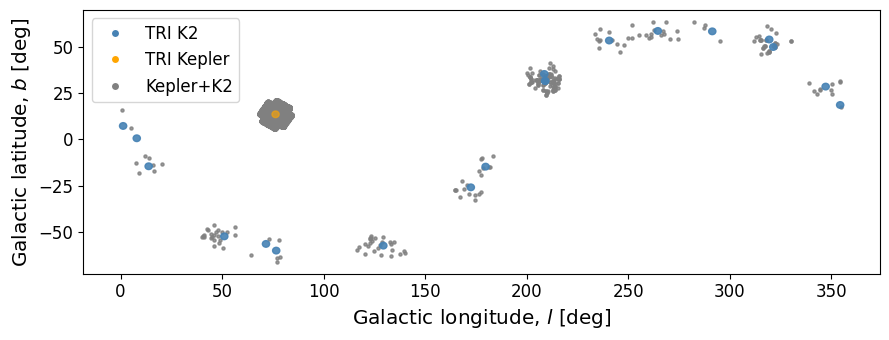

In [17]:
from matplotlib.lines import Line2D

# TRI
tri_k2_bs, tri_k2_ls = ra_dec_to_b_l(ras, decs)

fig, ax = plt.subplots(figsize=(9, 3.5))
for i in range(19):
    center = (tri_k2_ls[i].value, tri_k2_bs[i].value)
    
	# draw circle of radius sqrt(10), since the TRILEGAL queries have a window of 10 sq deg
    if i==0:
        circle = plt.Circle(center, np.sqrt(10/np.pi), alpha=0.9, color='steelblue', zorder=100, label='TRI K2')
    else:
        circle = plt.Circle(center, np.sqrt(10/np.pi), alpha=0.9, color='steelblue', zorder=100)

	# Add the circle to the axes
    ax.add_patch(circle)

# big faint circle for TRI Kepler
circle = plt.Circle((76.32, 13.5), np.sqrt(10/np.pi), alpha=0.6, color='orange', zorder=99, label='TRI Kepler')
ax.add_patch(circle)

# B23
k2_bs, k2_ls = ra_dec_to_b_l(hu25_b20_kepler_b25_k2['ra'], hu25_b20_kepler_b25_k2['dec'])

plt.scatter(k2_ls, k2_bs, label='Kepler+K2', s=5, alpha=0.8, color='gray')

obj1 = Line2D([], [], color="white", marker='o', markerfacecolor="steelblue")
obj2 = Line2D([], [], color="white", marker='o', markerfacecolor="orange")
obj3 = Line2D([], [], color="white", marker='o', markerfacecolor="gray")
plt.legend((obj1, obj2, obj3), ('TRI K2', 'TRI Kepler', 'Kepler+K2'))

plt.xlabel(r'Galactic longitude, $l$ [deg]')
plt.ylabel(r'Galactic latitude, $b$ [deg]')
plt.tight_layout()
plt.savefig(path+'plots/pointings.png')
plt.show()


At some point we're going to need to make cuts to conform with our sample's Kepmag distribution. So we need to cross-match our sample with the Bedell Gaia-Kepler cross-match to get Kepmag information. 

B23 didn't have kepmag. So I went to Exoplanet Archive's Table Access Protocol (TAP; https://exoplanetarchive.ipac.caltech.edu/docs/program_interfaces.html#k2) and queried all K2 targets there. Don't say I didn't do nothin

In [49]:
bedell = Table.read(path+'data/kepler_dr3_good.fits')
bedell_df = bedell.to_pandas()

k2candidates = pd.read_csv(path+'data/k2/k2candidates.csv', sep=',')

In [51]:
k2candidates.columns

Index(['epic_number', 'tm_name', 'k2_campaign_str', 'k2_type', 'rastr',
       'decstr', 'k2_propid', 'k2_dist', 'k2_disterr1', 'k2_disterr2',
       'k2_teff', 'k2_tefferr1', 'k2_tefferr2', 'k2_rad', 'k2_raderr1',
       'k2_raderr2', 'k2_mass', 'k2_masserr1', 'k2_masserr2', 'k2_kepmag',
       'k2_kepmagerr', 'k2_kepmagflag', 'k2_vjmag', 'k2_vjmagerr', 'k2_kmag',
       'k2_kmagerr'],
      dtype='object')

       Kepler_ID  Teff  e_Teff   logg  e_logg       Lum     e_Lum  [Fe/H]  \
0      7015160.0  5167     151  4.468   0.069  0.505556  0.043132   0.133   
1      7262873.0  5694     167  4.231   0.069  1.682723  0.124291   0.054   
2      6184474.0  5310     156  4.402   0.083  0.702968  0.054962   0.160   
3      6668281.0  5772     169  4.401   0.070  1.102606  0.083086   0.089   
4      9516660.0  5517     162  4.363   0.076  0.978101  0.090228   0.151   
...          ...   ...     ...    ...     ...       ...       ...     ...   
25301        NaN  4606     135  4.601   0.069  0.181332  0.012966  -0.330   
25302        NaN  5726     168  4.462   0.066  0.847420  0.066735  -0.075   
25303        NaN  5988     175  4.382   0.075  1.422034  0.120451  -0.238   
25304        NaN  5567     163  4.422   0.067  0.811818  0.059661   0.002   
25305        NaN  5792     170  4.414   0.080  1.020128  0.084903  -0.426   

       e_[Fe/H]    Rad  ...  ra_error  dec_error    age  age_err1  age_err2

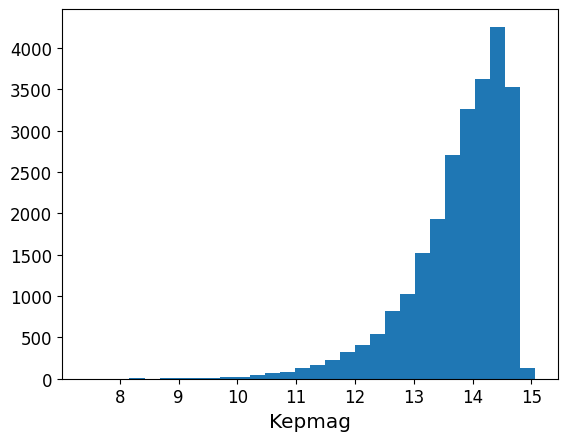

In [53]:
hu25_b20_kepler_b25_k2_kepmag_kepler = pd.merge(hu25_b20_kepler_b25_k2, bedell_df[['kepid', 'kepmag']], left_on='Kepler_ID', right_on='kepid') 
#print(hu25_b20_kepler_b25_k2_kepmag)
hu25_b20_kepler_b25_k2_kepmag_k2 = pd.merge(hu25_b20_kepler_b25_k2, k2candidates[['epic_number', 'k2_kepmag']], left_on='EPIC_ID', right_on='epic_number') 
hu25_b20_kepler_b25_k2_kepmag = pd.concat([hu25_b20_kepler_b25_k2_kepmag_kepler, hu25_b20_kepler_b25_k2_kepmag_k2], ignore_index=True)
print(hu25_b20_kepler_b25_k2_kepmag)

plt.hist(hu25_b20_kepler_b25_k2_kepmag['kepmag'], bins=30)
plt.xlabel('Kepmag')
plt.show()


Kepler

In [54]:
hu25_b20_kepler_b25_k2_kepmag.columns

Index(['Kepler_ID', 'Teff', 'e_Teff', 'logg', 'e_logg', 'Lum', 'e_Lum',
       '[Fe/H]', 'e_[Fe/H]', 'Rad', 'e_Rad', 'Mass', 'e_Mass', 'CDPP75',
       'CDPP6', 'KIC', 'iso_teff', 'iso_logg', 'iso_lum', 'iso_age',
       'iso_age_err1', 'iso_age_err2', 'iso_feh', 'kepid_x', 'source_id', 'ra',
       'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'radial_velocity', 'radial_velocity_error', 'height',
       'EPIC_ID', 'GaiaDR3', 'Campaign', 'CDPP8', 'EPIC', 'L_star', 'Age',
       'E_Age', 'e_Age', 'feh', 'SOURCE_ID', 'ra_error', 'dec_error', 'age',
       'age_err1', 'age_err2', 'kepid_y', 'kepmag', 'kepid', 'epic_number',
       'k2_kepmag'],
      dtype='object')

In [55]:
stem = 'data/kepler/trilegal/' 
filenames = os.listdir(path+stem)
filenames = [item for item in filenames if '.txt' in item] # omit directory name "luke"

tri_kepler = pd.DataFrame()
for i in range(len(filenames)):

	temp_kepler = pd.read_csv(path+stem+filenames[i], sep='\s+')
	temp_kepler.dropna(subset=['logAge','m2/m1'], inplace=True)

	# remove end lines from TRILEGAL, if applicable
	try:
		temp_kepler = temp_kepler[~temp_kepler['logAge'].str.contains('normally', na=False)]
	except:
		pass

	# add height column, introducing a spread of 0.05 dex based on TRILEGAL distance modulus bin size
	temp_kepler['distance'] = simulate_helpers.distance_modulus_to_distance(temp_kepler['m-M0'], perturb=True)
	temp_kepler['height'] = simulate_helpers.dist_kepler_to_height(temp_kepler['distance'])

	tri_kepler = pd.concat([tri_kepler, temp_kepler])

print("initial TRI: ", len(tri_kepler))

# remove binaries
tri_kepler = tri_kepler[tri_kepler['m2/m1']==0]
print("cut binaries: ", len(tri_kepler))

# unlog Teff. keep FGK dwarfs below Kraft break only
tri_kepler['Teff'] = 10**tri_kepler['logTe'].astype(float)
#tri_kepler = tri_kepler.loc[(tri_kepler['Teff'] <= 6500) & (tri_kepler['Teff'] >= 4000)] 
tri_kepler = tri_kepler.loc[(tri_kepler['Teff'] <= np.max(hu25_b20_kepler_b25_k2_kepmag['Teff'])) & (tri_kepler['Teff'] >= np.min(hu25_b20_kepler_b25_k2_kepmag['Teff']))] # match B20
print("Teff cut: ", len(tri_kepler))
print("max Teff: ", np.max(tri_kepler['Teff']))
print("min Teff: ", np.min(tri_kepler['Teff']))

# calculate stellar radius
tri_kepler['stellar_radius'] = simulate_helpers.stellar_radius_stefan_boltzmann(10**tri_kepler['logTe'], 10**tri_kepler['logL'])

# remove giant based on Z23 prescription, which uses Huber+16 prescription (see kepler_k2.ipynb, when I did it to the real sample)
#tri_kepler['logR'] = np.log10(tri_kepler['stellar_radius'])
#tri_kepler['is_giant'] = np.where(tri_kepler['logR'] >= 0.00035*(tri_kepler['Teff'] - 4500) + 0.15, True, False)
#tri_kepler = tri_kepler.loc[tri_kepler['is_giant'] == False]
logg_threshold_huber_2016 = np.arctan((6300 - tri_kepler['Teff'])/67.172)/4.671 + 3.876
tri_kepler = tri_kepler.loc[tri_kepler['logg'] >= logg_threshold_huber_2016]
print("cut giants via logg: ", len(tri_kepler))
print("max logg: ", np.max(tri_kepler['logg']))
print("min logg: ", np.min(tri_kepler['logg']))

# remove poofy stars, same as B20
#tri_kepler = tri_kepler.loc[(tri_kepler['logg']<4.7) & (tri_kepler['logg']>3.6)]
#tri_kepler = tri_kepler.loc[(tri_kepler['logg']<4.7) & (tri_kepler['logg']>4.)]
#print("logg cut: ", len(tri_kepler))

# TRILEGAL logAge bin size is 0.02, so let's introduce a spread of that size; note from Luke Bouma (https://github.com/lgbouma/gyrojo/blob/main/gyrojo/trilegal.py#L92-L108)
eps = np.random.normal(loc=0, scale=0.02, size=len(tri_kepler))
tri_kepler['logAge'] = tri_kepler['logAge'].astype(float)
tri_kepler['logAge'] += eps
tri_kepler['age'] = 10**tri_kepler['logAge'].astype(float) / 1e9

# remove PMS stars
tri_kepler = tri_kepler.loc[tri_kepler['age']>0.5]

# get rid of low metallicity stars because their Teff-logg relation is different
#tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)>=-0.6] # this is different from Fe/H cut for B20, but we only have apples v oranges
#tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)<=0.3] # this is different from Fe/H cut for B20, but we only have apples v oranges
#tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)>=-0.25] # this is different from Fe/H cut for B20, but we only have apples v oranges
#tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)<=0.25]
#print("metallicity cut: ", len(tri_kepler))

# same age cut as sample
tri_kepler = tri_kepler.loc[tri_kepler['age'] <= 14.] 
#print("min age: ", np.min(hu25_b20_kepler_b25_k2_kepmag['Age']))
#tri_kepler = tri_kepler.loc[tri_kepler['age'] >= np.min(hu25_b20_kepler_b25_k2_kepmag['Age'])] 
print("age cut: ", len(tri_kepler))

# make an additional cut on Kepler magnitude
tri_kepler = tri_kepler.loc[(tri_kepler['Kepler'] <= np.max(hu25_b20_kepler_b25_k2_kepmag['kepmag'])) & (tri_kepler['Kepler'] >= np.min(hu25_b20_kepler_b25_k2_kepmag['kepmag']))] 
print("kepmag cut: ", len(tri_kepler))
print("min kepmag: ", np.min(hu25_b20_kepler_b25_k2_kepmag['kepmag']))
print("max kepmag: ", np.max(hu25_b20_kepler_b25_k2_kepmag['kepmag']))

# extrapolate CDPP based on Zink+20
#my_k2 = simulate_helpers.kepmag_to_cdpp_vectorized(k2_stars, my_k2) # cdpp distribution is similar to B20 sample

tri_kepler = tri_kepler.reset_index()
tri_kepler


initial TRI:  280647
cut binaries:  132951
Teff cut:  110635
max Teff:  6486.344335482381
min Teff:  4083.1938633269233
cut giants via logg:  70741
max logg:  5.029
min logg:  3.635
age cut:  68338
kepmag cut:  28423
min kepmag:  7.397
max kepmag:  15.068


,index,#Gc,logAge,[M/H],m_ini,logL,logTe,logg,m-M0,Av,...,DDO51_finf,J,H,Ks,Mact,distance,height,Teff,stellar_radius,age
0,1167,1,8.707909,-0.13,0.95062,-0.212,3.743,4.547,9.246381,0.030,...,14.821,13.361,12.997,12.948,0.951,706.766928,164.991463,5533.501092,0.854449,0.510398
1,1173,1,8.705078,-0.05,0.99828,-0.123,3.751,4.511,9.074673,0.029,...,14.462,13.069,12.725,12.679,0.998,653.032203,152.447340,5636.376558,0.912402,0.507082
2,1198,1,8.719435,0.17,1.13006,0.099,3.771,4.420,9.310207,0.031,...,14.088,12.839,12.551,12.511,1.130,727.849109,169.913000,5902.010802,1.074450,0.524125
3,1232,1,8.702060,-0.01,0.56323,-1.225,3.611,4.805,6.111296,0.012,...,15.546,12.301,11.640,11.518,0.563,166.824250,38.944348,4083.193863,0.488862,0.503570
4,1234,1,8.720791,-0.01,1.04565,-0.028,3.761,4.475,9.745395,0.032,...,14.793,13.474,13.154,13.112,1.046,889.363055,207.617682,5767.664634,0.972045,0.525765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28418,32327,2,10.063690,-0.57,0.79794,-0.155,3.759,4.477,7.767594,0.020,...,13.063,11.755,11.421,11.379,0.798,357.699842,83.503370,5741.164622,0.847591,11.579513
28419,32373,2,10.101758,-0.55,0.83839,0.007,3.773,4.392,9.270473,0.030,...,14.231,13.017,12.713,12.676,0.838,714.651934,166.832181,5929.253246,0.957604,12.640322
28420,32445,2,10.093861,-0.51,0.88163,0.181,3.781,4.273,10.128001,0.034,...,14.579,13.423,13.136,13.102,0.882,1060.718812,247.619889,6039.486294,1.127681,12.412547
28421,32499,2,10.101271,-0.47,0.87357,0.121,3.778,4.315,10.344720,0.035,...,15.036,13.854,13.561,13.525,0.874,1172.044269,273.608301,5997.910763,1.067053,12.626138


In [74]:
import os
import re

stem = 'data/k2/trilegal/campaign' 
filenames = os.listdir(path+'data/k2/trilegal/')
tri_k2 = pd.DataFrame()
for i in range(len(filenames)):
	
	# there's a test file in this directory. skip it.
	if 'test' in filenames[i]:
		continue

	#temp_k2 = pd.read_csv(path+stem+f'{i+1}.dat.txt', sep='\s+')
	temp_k2 = pd.read_csv(path+'data/k2/trilegal/'+filenames[i], sep='\s+')
	temp_k2.dropna(subset=['logAge','m2/m1'], inplace=True)

	# remove end lines from TRILEGAL, if applicable
	try:
		temp_k2 = temp_k2[~temp_k2['logAge'].str.contains('normally', na=False)]
	except:
		pass

	# based on campaign, grab b of the pointing
	#temp_campaign = int(i)
	temp_campaign = int(re.search('campaign(.+?).dat', filenames[i]).group(1))
	temp_b = k2_pointings['b'][temp_campaign-1]
	#temp_b = k2_pointings[k2_pointings['campaign']==temp_campaign]['b']

	# add height column, introducing a spread of 0.05 dex based on TRILEGAL distance modulus bin size
	temp_k2['distance'] = simulate_helpers.distance_modulus_to_distance(temp_k2['m-M0'], perturb=True)
	temp_k2['height'] = dist_k2_to_height(temp_k2['distance'], temp_b)

	# add column for campaign and for whether it's high or low Galactic latitude
	temp_k2['campaign'] = temp_campaign

	tri_k2 = pd.concat([tri_k2, temp_k2])

print("initial TRI: ", len(tri_k2))

# remove binaries
tri_k2 = tri_k2[tri_k2['m2/m1']==0]
print("cut binaries: ", len(tri_k2))

# unlog Teff. keep FGK dwarfs below Kraft break only
tri_k2['Teff'] = 10**tri_k2['logTe'].astype(float)
#tri_k2 = tri_k2.loc[(tri_k2['Teff'] <= 6500) & (tri_k2['Teff'] >= 4000)] 
tri_k2 = tri_k2.loc[(tri_k2['Teff'] <= np.max(hu25_b20_kepler_b25_k2_kepmag['Teff'])) & (tri_k2['Teff'] >= np.min(hu25_b20_kepler_b25_k2_kepmag['Teff']))] # match B20
print("Teff cut: ", len(tri_k2))
print("max Teff: ", np.max(tri_k2['Teff']))
print("min Teff: ", np.min(tri_k2['Teff']))

# calculate stellar radius
tri_k2['stellar_radius'] = simulate_helpers.stellar_radius_stefan_boltzmann(10**tri_k2['logTe'], 10**tri_k2['logL'])

# remove giant based on Z23 prescription, which uses Huber+16 prescription (see kepler_k2.ipynb, when I did it to the real sample)
#tri_kepler['logR'] = np.log10(tri_kepler['stellar_radius'])
#tri_kepler['is_giant'] = np.where(tri_kepler['logR'] >= 0.00035*(tri_kepler['Teff'] - 4500) + 0.15, True, False)
#tri_kepler = tri_kepler.loc[tri_kepler['is_giant'] == False]
logg_threshold_huber_2016 = np.arctan((6300 - tri_k2['Teff'])/67.172)/4.671 + 3.876
tri_k2 = tri_k2.loc[tri_k2['logg'] >= logg_threshold_huber_2016]
print("cut giants via logg: ", len(tri_k2))
print("max logg: ", np.max(tri_k2['logg']))
print("min logg: ", np.min(tri_k2['logg']))

# TRILEGAL logAge bin size is 0.02, so let's introduce a spread of that size; note from Luke Bouma (https://github.com/lgbouma/gyrojo/blob/main/gyrojo/trilegal.py#L92-L108)
eps = np.random.normal(loc=0, scale=0.02, size=len(tri_k2))
tri_k2['logAge'] = tri_k2['logAge'].astype(float)
tri_k2['logAge'] += eps
tri_k2['age'] = 10**tri_k2['logAge'].astype(float) / 1e9

# tri_k2 = tri_k2.loc[tri_k2['[M/H]'].astype(float)>=-0.25] # this is different from Fe/H cut for B23, but we only have apples v oranges
# tri_k2 = tri_k2.loc[tri_k2['[M/H]'].astype(float)<=0.25]
# print("metallicity cut: ", len(tri_k2))

# age cut for uniformity
tri_k2 = tri_k2.loc[(tri_k2['age'] <= 12.) & (tri_k2['age'] >= 0.5)]
#print("min age: ", np.min(k2_stars_bootstrapped['age']))
#tri_k2 = tri_k2.loc[tri_k2['age'] >= np.min(k2_stars_bootstrapped['age'])] 
print("age cut: ", len(tri_k2))

# make an additional cut on Kepler magnitude
tri_k2 = tri_k2.loc[(tri_k2['Kepler'] <= np.max(hu25_b20_kepler_b25_k2_kepmag['k2_kepmag'])) & (tri_k2['Kepler'] >= np.min(hu25_b20_kepler_b25_k2_kepmag['k2_kepmag']))] 
print("kepmag cut: ", len(tri_k2))

# extrapolate CDPP based on Zink+20
#my_k2 = simulate_helpers.kepmag_to_cdpp_vectorized(k2_stars, my_k2) # cdpp distribution is similar to B20 sample

tri_k2 = tri_k2.reset_index()
tri_k2


initial TRI:  842457
cut binaries:  496124
Teff cut:  151243
max Teff:  6486.344335482381
min Teff:  4083.1938633269233
cut giants via logg:  68990
max logg:  5.034
min logg:  3.623
age cut:  63320
kepmag cut:  31694


,index,#Gc,logAge,[M/H],m_ini,logL,logTe,logg,m-M0,Av,...,J,H,Ks,Mact,distance,height,campaign,Teff,stellar_radius,age
0,32,1,8.743292,-0.09,0.73063,-0.767,3.666,4.679,7.941054,0.037,...,13.125,12.536,12.450,0.731,387.445741,202.519818,5,4634.469197,0.642963,0.553722
1,41,1,8.809161,0.23,0.83782,-0.555,3.684,4.599,8.527471,0.037,...,13.237,12.716,12.637,0.838,507.568002,265.308322,5,4830.588020,0.755416,0.644408
2,44,1,8.858244,0.11,0.61232,-1.117,3.620,4.767,6.895718,0.034,...,12.807,12.131,12.014,0.612,239.410678,125.141153,5,4168.693835,0.531112,0.721513
3,45,1,8.846451,0.17,1.00134,-0.163,3.740,4.506,7.121281,0.034,...,11.010,10.647,10.595,1.001,265.617189,138.839427,5,5495.408739,0.916613,0.702184
4,55,1,8.876216,0.21,0.79699,-0.653,3.670,4.620,6.112276,0.030,...,11.088,10.522,10.437,0.797,166.899590,87.239247,5,4677.351413,0.719757,0.751997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31689,3555,2,10.071248,-0.57,0.74817,-0.354,3.736,4.557,8.495296,0.037,...,12.958,12.570,12.517,0.748,500.102747,382.252610,6,5445.026528,0.749353,11.782776
31690,3585,2,10.050118,-0.53,0.82839,-0.051,3.768,4.424,9.842365,0.038,...,13.640,13.324,13.284,0.828,929.978712,710.827510,6,5861.381645,0.916613,11.223223
31691,3595,2,10.038573,-0.51,0.79752,-0.191,3.753,4.491,9.010776,0.037,...,13.124,12.776,12.731,0.798,634.096274,484.670315,6,5662.392890,0.835961,10.928801
31692,3618,2,10.067328,-0.45,0.85247,0.015,3.771,4.382,8.861147,0.037,...,12.584,12.276,12.238,0.852,591.874247,452.397986,6,5902.010802,0.975408,11.676900


In [75]:
hu25_b25_k2 = hu25_b20_kepler_b25_k2_kepmag.loc[hu25_b20_kepler_b25_k2_kepmag['KIC'].isna()]
hu25_b20_kepler = hu25_b20_kepler_b25_k2_kepmag.loc[hu25_b20_kepler_b25_k2_kepmag['epic_number'].isna()]
print(len(hu25_b20_kepler))
print(len(hu25_b25_k2))

24883
423


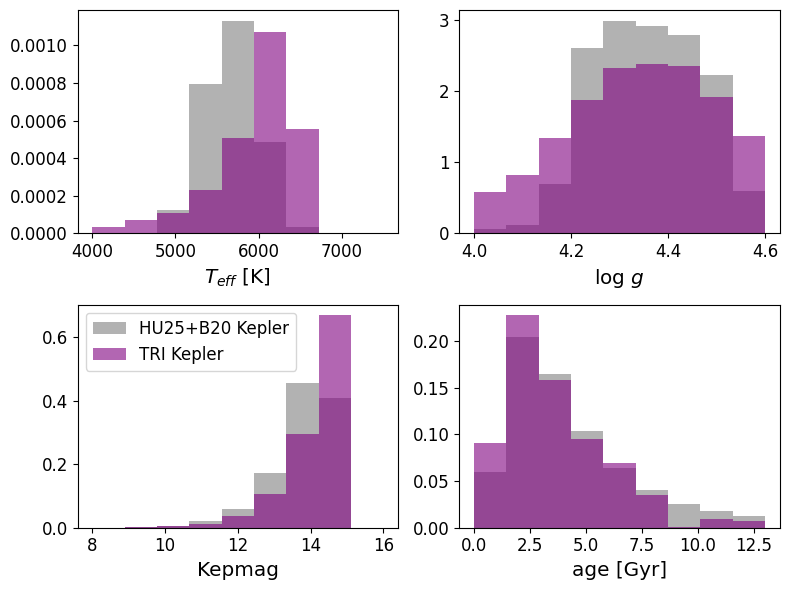

In [77]:
cols = ["iso_teff", "iso_logg", "kepmag", "iso_age"]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

ax = axes[0]
teff_bins = np.linspace(4000, 7500, 10)
ax.hist(hu25_b20_kepler['Teff'], bins=teff_bins, alpha=0.6, label="HU25+B20 Kepler", density=True, color='gray')
ax.hist(tri_kepler['Teff'], bins=teff_bins, alpha=0.6, label="TRI Kepler", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['Teff'], bins=teff_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r"$T_{eff}$ [K]")

ax = axes[1]
logg_bins = np.linspace(4., 4.6, 10)
ax.hist(hu25_b20_kepler['logg'], bins=logg_bins, alpha=0.6, label="HU25+B20 Kepler", density=True, color='gray')
ax.hist(tri_kepler['logg'], bins=logg_bins, alpha=0.6, label="TRI Kepler", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['logg'], bins=logg_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'log $g$')

ax = axes[2]
kepmag_bins = np.linspace(8, 16, 10)
ax.hist(hu25_b20_kepler['kepmag'], bins=kepmag_bins, alpha=0.6, label="HU25+B20 Kepler", density=True, color='gray')
ax.hist(tri_kepler['Kepler'], bins=kepmag_bins, alpha=0.6, label="TRI Kepler", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['kepmag'], bins=kepmag_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'Kepmag')
ax.legend(loc='upper left')

ax = axes[3]
age_bins = np.linspace(0, 13, 10)
ax.hist(hu25_b20_kepler['age'], bins=age_bins, alpha=0.6, label="HU25+B20 Kepler", density=True, color='gray')
ax.hist(tri_kepler['age'], bins=age_bins, alpha=0.6, label="TRI Kepler", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['age'], bins=age_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'age [Gyr]')

plt.tight_layout()
plt.savefig(path+'plots/tri_vs_sample_params_kepler.png')
plt.show()

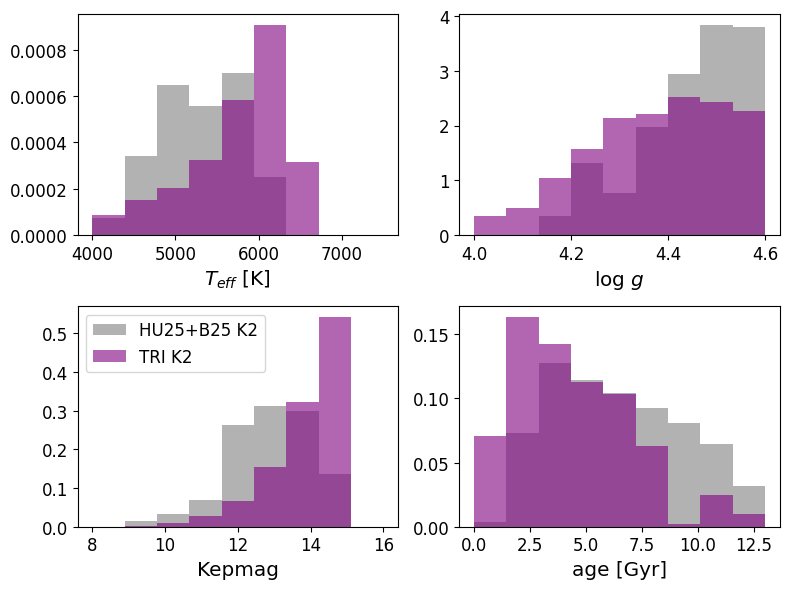

In [79]:
cols = ["iso_teff", "iso_logg", "kepmag", "iso_age"]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

ax = axes[0]
teff_bins = np.linspace(4000, 7500, 10)
ax.hist(hu25_b25_k2['Teff'], bins=teff_bins, alpha=0.6, label="HU25+B25 K2", density=True, color='gray')
ax.hist(tri_k2['Teff'], bins=teff_bins, alpha=0.6, label="TRI K2", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['Teff'], bins=teff_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r"$T_{eff}$ [K]")

ax = axes[1]
logg_bins = np.linspace(4., 4.6, 10)
ax.hist(hu25_b25_k2['logg'], bins=logg_bins, alpha=0.6, label="HU25+B25 K2", density=True, color='gray')
ax.hist(tri_k2['logg'], bins=logg_bins, alpha=0.6, label="TRI K2", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['logg'], bins=logg_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'log $g$')

ax = axes[2]
kepmag_bins = np.linspace(8, 16, 10)
ax.hist(hu25_b25_k2['k2_kepmag'], bins=kepmag_bins, alpha=0.6, label="HU25+B25 K2", density=True, color='gray')
ax.hist(tri_k2['Kepler'], bins=kepmag_bins, alpha=0.6, label="TRI K2", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['kepmag'], bins=kepmag_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'Kepmag')
ax.legend(loc='upper left')

ax = axes[3]
age_bins = np.linspace(0, 13, 10)
ax.hist(hu25_b25_k2['age'], bins=age_bins, alpha=0.6, label="HU25+B25 K2", density=True, color='gray')
ax.hist(tri_k2['age'], bins=age_bins, alpha=0.6, label="TRI K2", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['age'], bins=age_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'age [Gyr]')

plt.tight_layout()
plt.savefig(path+'plots/tri_vs_sample_params_k2.png')
plt.show()

In [ ]:
tri = pd.concat([tri_kepler, tri_k2], ignore_index=True)

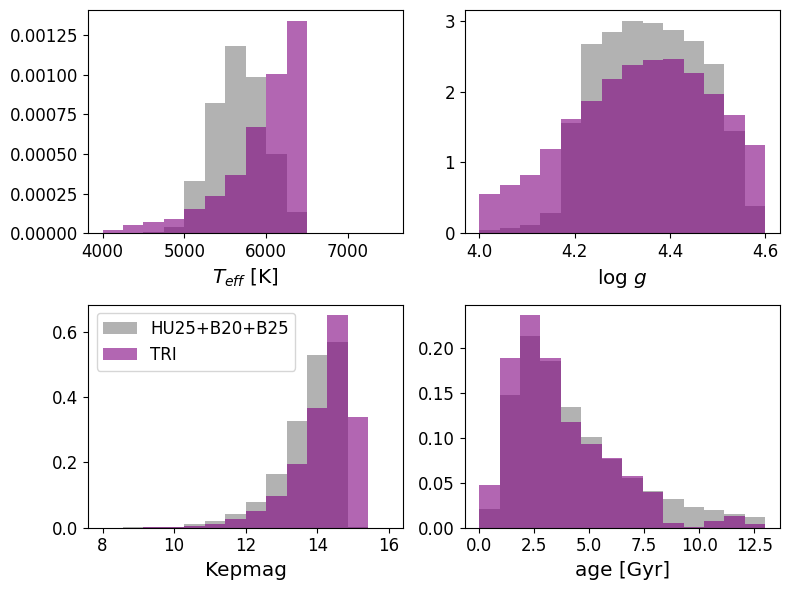

In [ ]:
cols = ["iso_teff", "iso_logg", "kepmag", "iso_age"]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

ax = axes[0]
teff_bins = np.linspace(4000, 7500, 15)
ax.hist(hu25_b20_kepler_b25_k2_kepmag['Teff'], bins=teff_bins, alpha=0.6, label="HU25+B20+B25", density=True, color='gray')
ax.hist(tri['Teff'], bins=teff_bins, alpha=0.6, label="TRI", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['Teff'], bins=teff_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r"$T_{eff}$ [K]")

ax = axes[1]
logg_bins = np.linspace(4., 4.6, 15)
ax.hist(hu25_b20_kepler_b25_k2_kepmag['logg'], bins=logg_bins, alpha=0.6, label="HU25+B20+B25", density=True, color='gray')
ax.hist(tri['logg'], bins=logg_bins, alpha=0.6, label="TRI", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['logg'], bins=logg_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'log $g$')

ax = axes[2]
kepmag_bins = np.linspace(8, 16, 15)
ax.hist(hu25_b20_kepler_b25_k2_kepmag['kepmag'], bins=kepmag_bins, alpha=0.6, label="HU25+B20+B25", density=True, color='gray')
ax.hist(tri['Kepler'], bins=kepmag_bins, alpha=0.6, label="TRI", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['kepmag'], bins=kepmag_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'Kepmag')
ax.legend(loc='upper left')

ax = axes[3]
age_bins = np.linspace(0, 13, 15)
ax.hist(hu25_b20_kepler_b25_k2_kepmag['age'], bins=age_bins, alpha=0.6, label="HU25+B20+B25", density=True, color='gray')
ax.hist(tri['age'], bins=age_bins, alpha=0.6, label="TRI", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['age'], bins=age_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'age [Gyr]')

plt.tight_layout()
plt.savefig(path+'plots/tri_vs_sample_params.png')
plt.show()